### **Лаба 1, краткая информация, что сделать, кто участвовал, какие части делал. вводную инфу добавить в общем**

### Include necessary frameworks

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf # only for loading dataset

### Loading and preprocess data

In [ ]:
# Loading from Tensorflow.Keras
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train.shape, # 60 thousand of handwritten digits in size 28 x 28 pixels (3D-array), values from 0 to 255
      y_train.shape) # 60 thousand of correct digits (1D-array), target variables

(60000, 28, 28) (60000,)


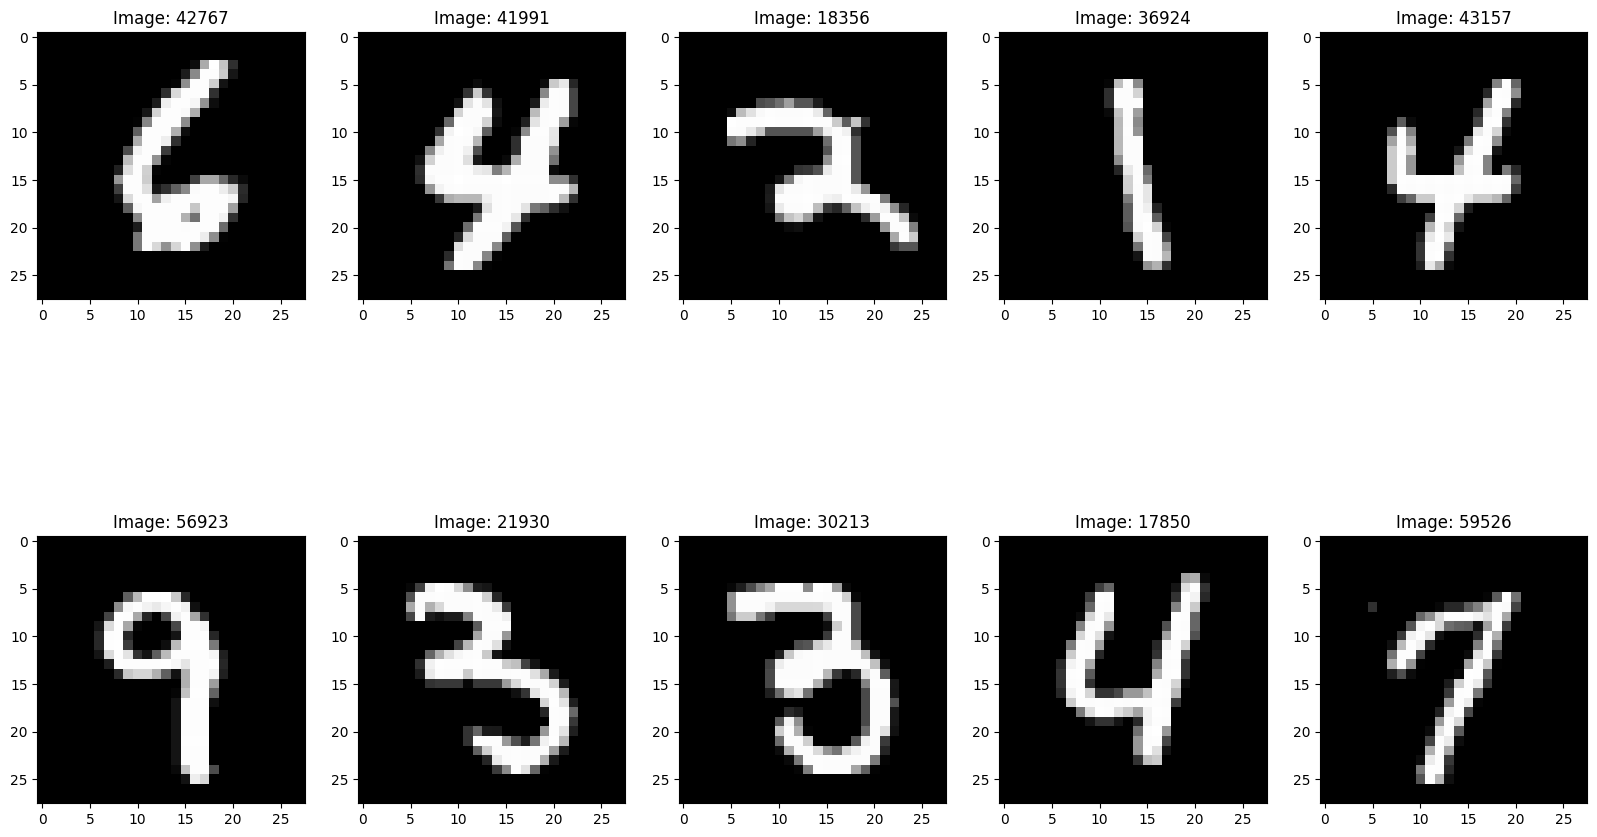

In [ ]:
x_train, x_test = x_train / 255, x_test / 255 # normalization (from 0 to 1)

# vizualization of the dataset
fig, ax = plt.subplots(2, 5, figsize=(20,12))
rand_samples = np.random.randint(0, len(x_train), (2,5))
for i in range(2):
  for j in range(5):
    ax[i][j].imshow(x_train[rand_samples[i][j]], cmap="grey")
    ax[i][j].set_title(f"Image: {rand_samples[i][j]}")
    plt.show

In [ ]:
# Flattening images (60000 * 28 * 28 -> 60000 * 784)
x_train_flat = x_train.reshape(len(x_train), (28*28)) # 60000 * 784
x_test_flat = x_test.reshape(len(x_test), (28*28)) # 10000 * 784

x_train_flat[0][150:250] # now image is presented in vector with size (1 * 784)

array([0.        , 0.        , 0.01176471, 0.07058824, 0.07058824,
       0.07058824, 0.49411765, 0.53333333, 0.68627451, 0.10196078,
       0.65098039, 1.        , 0.96862745, 0.49803922, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.11764706, 0.14117647, 0.36862745, 0.60392157,
       0.66666667, 0.99215686, 0.99215686, 0.99215686, 0.99215686,
       0.99215686, 0.88235294, 0.6745098 , 0.99215686, 0.94901961,
       0.76470588, 0.25098039, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.19215686, 0.93333333,
       0.99215686, 0.99215686, 0.99215686, 0.99215686, 0.99215686,
       0.99215686, 0.99215686, 0.99215686, 0.98431373, 0.36470588,
       0.32156863, 0.32156863, 0.21960784, 0.15294118, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
# Encoding traget variable for further convenient use
def onehot(np_array):
  """One-hot encoding digits from y_train to 2D-array (60000, 10) with "1" in position [digit]"""
  res = np.zeros((len(np_array), len(np.unique(np_array))))
  for i in range(len(np_array)):
    res[i][np_array[i]] = 1
  return res

y_train_onehot = onehot(y_train) # 60000 * 10
y_test_onehot = onehot(y_test) # 10000 * 10

y_train_onehot[0] # first digit is 5. It is represented as 1 on 5th index of first row

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

### Neural Network classes definition


In [ ]:
class Layer():
  """Base abstract class"""

  def forward_prop():
    pass

  def backward_prop():
    pass

class LinearLayer(Layer):
  """Derived class with weights and biases to calculate values through it"""

  def __init__(self, input_size, output_size):
    self.weights = np.random.rand(input_size, output_size)
    self.bias = np.zeros((1, output_size))
    self.dw = None
    self.db = None
    self.input = None

  def forward_prop(self, input_vals):
    self.input = input_vals
    return input_vals @ self.weights + self.bias

  def backward_prop(self, output_vals):
    self.dw = self.input.T @ output_vals
    self.db = np.sum(output_vals, axis=0, keepdims=True)
    return output_vals @ self.weights.T

class ReLU(Layer):
  """Class of activation function after hidden neurons that returns 0 or positive value"""

  def forward_prop(self, input_vals):
    self.input = input_vals
    self.output = np.maximum(0, input_vals)
    return self.output

  def backward_prop(self, output_vals):
    return output_vals * (self.input > 0)

class Softmax(Layer):
  """Class of final activation function that converts logits into probalities"""

  def forward_prop(self, input_vals):
    shifted = input_vals - np.max(input_vals, axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    self.output = exp_vals / np.sum(exp_vals, axis=1, keepdims=True)
    return self.output

  def backward_prop():
    pass

class CrossEntropy(Layer):
  """Class of loss-function"""
  def forward_prop(self, logits, targets):
    self.logits = logits
    self.targets = targets
    batch_size = logits.shape[0]
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_shifted = np.exp(shifted)
    self.probs = exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)
    eps = 1e-15
    self.probs = np.clip(self.probs, eps, 1 - eps)
    loss = -np.sum(targets * np.log(self.probs)) / batch_size
    return loss

  def backward_prop(self):
    batch_size = self.logits.shape[0]
    return (self.probs - self.targets) / batch_size

class GradientDescend(Layer):
  """Class of optimization-function"""
  def __init__(self, learning_rate=0.01):
        self.lr = learning_rate

  def step(self, layers):
    for layer in layers:
      if hasattr(layer, 'weights'):
        layer.weights -= self.lr * layer.dw
        layer.bias -= self.lr * layer.db

class NeuralNetwork():
  """Sequential class that holds and manages layers inside Neural Network"""

  def __init__(self):
    self.layers = []
    self.loss_func = None # MSE / Cross Entropy
    self.optimizer = None

  def add_layer(self, layer):
    self.layers.append(layer)

  def set_loss(self, loss_fn):
    self.loss_fn = loss_fn

  def set_optimizer(self, optimizer):
    self.optimizer = optimizer

  def forward_prop(self, input_vals):
    output = input_vals
    for layer in self.layers:
      output = layer.forward_prop(output)
    return output

  def backward_prop(self, output_vals):
    grad = output_vals
    for layer in reversed(self.layers):
      grad = layer.backward_prop(grad)
    return grad

  def train_step(self, x, y):
    logits = self.forward_prop(x)
    loss = self.loss_fn.forward_prop(logits, y)
    dlogits = self.loss_fn.backward_prop()
    self.backward_prop(dlogits)
    self.optimizer.step(self.layers)
    return loss

  def predict(self, x):
    logits = self.forward_prop(x)
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    probs = exp_vals / np.sum(exp_vals, axis=1, keepdims=True)
    return probs

  def accuracy(self, x, y):
    probs = self.predict(x)
    preds = np.argmax(probs, axis=1)
    true = np.argmax(y, axis=1)
    return np.mean(preds == true)

  def parameters():
    # need an implementation
    pass

  def gradients():
    # need an implementation
    pass

### Training and evaluating the model

In [ ]:
# Initializing layers
layer1 = LinearLayer(784, 128)
layer1_relu = ReLU()
layer2 = LinearLayer(128, 10)
layer_softmax = Softmax()

# Initializing the Network
MyNN = NeuralNetwork()
MyNN.add_layer(layer1)
MyNN.add_layer(layer1_relu)
MyNN.add_layer(layer2)
MyNN.add_layer(layer_softmax)

# Forward propagation of unlearned model
for i in range(10):
  output = MyNN.forward_prop(x_train_flat[i])
  print(f"Array of probabilities for {i} image: {np.round(output, decimals=2)}")

Array of probabilities for 0 image: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Array of probabilities for 1 image: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Array of probabilities for 2 image: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Array of probabilities for 3 image: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Array of probabilities for 4 image: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Array of probabilities for 5 image: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Array of probabilities for 6 image: [[0.   0.   0.   0.   0.   0.   0.01 0.   0.   0.99]]
Array of probabilities for 7 image: [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]
Array of probabilities for 8 image: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Array of probabilities for 9 image: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [ ]:
model1 = NeuralNetwork()
model1.add_layer(LinearLayer(784, 128))
model1.add_layer(ReLU())
model1.add_layer(LinearLayer(128, 10))
model1.set_loss(CrossEntropy())
model1.set_optimizer(GradientDescend(learning_rate=0.1))

epochs = 10
batch_size = 64
train_losses1 = []
test_accuracies1 = []

print("Обучение модели 1 (ReLU, 1 скрытый слой):")
for epoch in range(epochs):
    # Перемешиваем данные в начале каждой эпохи
    indices = np.random.permutation(len(x_train_flat))
    epoch_loss = 0
    num_batches = 0
    for i in range(0, len(x_train_flat), batch_size):
        batch_idx = indices[i:i+batch_size]
        x_batch = x_train_flat[batch_idx]
        y_batch = y_train_onehot[batch_idx]

        loss = model1.train_step(x_batch, y_batch)
        epoch_loss += loss
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    train_losses1.append(avg_loss)

    acc = model1.accuracy(x_test_flat, y_test_onehot)
    test_accuracies1.append(acc)
    print(f"Эпоха {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")

Обучение модели 1 (ReLU, 1 скрытый слой):
Эпоха 1/10, Loss: 2.5641, Test Acc: 0.3491
Эпоха 2/10, Loss: 1.4686, Test Acc: 0.5441
Эпоха 3/10, Loss: 1.0497, Test Acc: 0.7173
Эпоха 4/10, Loss: 0.8395, Test Acc: 0.7576
Эпоха 5/10, Loss: 0.7533, Test Acc: 0.6724
Эпоха 6/10, Loss: 0.7174, Test Acc: 0.7843
Эпоха 7/10, Loss: 0.6934, Test Acc: 0.7786
Эпоха 8/10, Loss: 0.6782, Test Acc: 0.7834
Эпоха 9/10, Loss: 0.6659, Test Acc: 0.8000
Эпоха 10/10, Loss: 0.6540, Test Acc: 0.7864


In [ ]:
class Tanh(Layer):
    def forward_prop(self, input_vals):
        self.input = input_vals
        self.output = np.tanh(input_vals)
        return self.output

    def backward_prop(self, dout):
        return dout * (1 - self.output**2)

model2 = NeuralNetwork()
model2.add_layer(LinearLayer(784, 256))
model2.add_layer(Tanh())
model2.add_layer(LinearLayer(256, 128))
model2.add_layer(Tanh())
model2.add_layer(LinearLayer(128, 10))
model2.set_loss(CrossEntropy())
model2.set_optimizer(GradientDescend(learning_rate=0.1))

train_losses2 = []
test_accuracies2 = []

print("\nОбучение модели 2 (Tanh, два скрытых слоя):")
for epoch in range(epochs):
    indices = np.random.permutation(len(x_train_flat))
    epoch_loss = 0
    num_batches = 0
    for i in range(0, len(x_train_flat), batch_size):
        batch_idx = indices[i:i+batch_size]
        x_batch = x_train_flat[batch_idx]
        y_batch = y_train_onehot[batch_idx]

        loss = model2.train_step(x_batch, y_batch)
        epoch_loss += loss
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    train_losses2.append(avg_loss)

    acc = model2.accuracy(x_test_flat, y_test_onehot)
    test_accuracies2.append(acc)
    print(f"Эпоха {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")


Обучение модели 2 (Tanh, два скрытых слоя):
Эпоха 1/10, Loss: 2.4669, Test Acc: 0.1135
Эпоха 2/10, Loss: 2.4656, Test Acc: 0.1010
Эпоха 3/10, Loss: 2.4593, Test Acc: 0.1028
Эпоха 4/10, Loss: 2.4545, Test Acc: 0.0892
Эпоха 5/10, Loss: 2.4658, Test Acc: 0.0980
Эпоха 6/10, Loss: 2.4580, Test Acc: 0.0892
Эпоха 7/10, Loss: 2.4579, Test Acc: 0.0958
Эпоха 8/10, Loss: 2.4578, Test Acc: 0.1032
Эпоха 9/10, Loss: 2.4660, Test Acc: 0.0974
Эпоха 10/10, Loss: 2.4506, Test Acc: 0.1032
